# Insurance Fraud Detection using Machine Learning
**Dataset:** Auto Insurance Claims (Kaggle)

**Goal:** Build a Machine Learning model that can predict whether an insurance claim is fraudulent or not.

**Steps we will follow:**
1. Install & Import Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Training (Random Forest)
6. Model Evaluation
7. Feature Importance


## Step 1: Install & Import Libraries

We need several Python libraries:
- `pandas` → for handling data (like Excel but in Python)
- `numpy` → for math operations
- `matplotlib` & `seaborn` → for making graphs/charts
- `sklearn` → the main ML library (scikit-learn)

In [ ]:
import pandas as pd          # For loading and working with data tables
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt  # For creating plots/charts
import seaborn as sns        # For prettier statistical charts
import warnings
warnings.filterwarnings('ignore')  # Hide unnecessary warnings

# ML libraries
from sklearn.model_selection import train_test_split   # To split data into train & test
from sklearn.preprocessing import LabelEncoder         # To convert text labels to numbers
from sklearn.ensemble import RandomForestClassifier    # Our main ML model
from sklearn.metrics import (classification_report,    # Detailed accuracy report
                              confusion_matrix,         # Shows correct vs wrong predictions
                              accuracy_score,           # Overall accuracy %
                              roc_auc_score,            # AUC score (how good the model is)
                              roc_curve)                # For drawing the ROC curve

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

We are using the **Auto Insurance Fraud Detection** dataset from Kaggle.

**How to get the dataset:**
1. Go to: https://www.kaggle.com/datasets/buntyshah/auto-insurance-claims-data
2. Download `insurance_claims.csv`


The dataset has **1000 rows** and **40 columns** about insurance claims.
The target column is `fraud_reported` — it is either `Y` (fraud) or `N` (not fraud).

In [ ]:
# Load the dataset into a DataFrame (a table in Python)
df = pd.read_csv('insurance_claims.csv')

# Show the first 5 rows to see what the data looks like
print('Shape of dataset:', df.shape)  # (rows, columns)
print('\nFirst 5 rows:')
df.head()

Shape of dataset: (1000, 40)

First 5 rows:


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [ ]:
# Check all column names
print('Columns in dataset:')
print(df.columns.tolist())

Columns in dataset:
['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39']


In [ ]:
# Check data types of each column and how many non-null values exist
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [ ]:
# Basic statistics (mean, min, max etc.) for numerical columns
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


## Step 3: Exploratory Data Analysis (EDA)

EDA means **exploring the data** before building the model.
We want to understand:
- How many fraud vs non-fraud cases are there?
- Are there any missing values?
- What patterns exist in the data?

In [ ]:
# --- Check for missing values ---
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0])  # Only show columns that have missing values

# Also check for '?' which this dataset uses instead of NaN for some columns
print('\nColumns with ? values:')
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f'  {col}: {count} missing values')

Missing values per column:
authorities_contacted      91
_c39                     1000
dtype: int64

Columns with ? values:
  collision_type: 178 missing values
  property_damage: 360 missing values
  police_report_available: 343 missing values


Fraud Distribution:
fraud_reported
N    753
Y    247
Name: count, dtype: int64

Fraud percentage: 24.7%


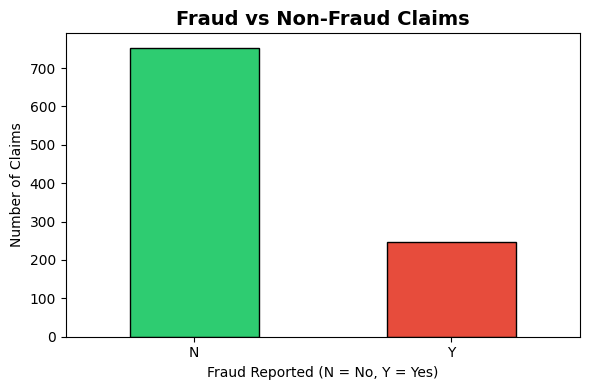

Chart saved!


In [ ]:
# --- Target Variable Distribution ---
# How many fraud (Y) vs not fraud (N) cases?

fraud_counts = df['fraud_reported'].value_counts()
print('Fraud Distribution:')
print(fraud_counts)
print(f'\nFraud percentage: {fraud_counts["Y"] / len(df) * 100:.1f}%')

# Plot it
plt.figure(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']  # Green for No fraud, Red for Fraud
fraud_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Fraud vs Non-Fraud Claims', fontsize=14, fontweight='bold')
plt.xlabel('Fraud Reported (N = No, Y = Yes)')
plt.ylabel('Number of Claims')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fraud_distribution.png', dpi=150)  # Save the chart
plt.show()
print('Chart saved!')

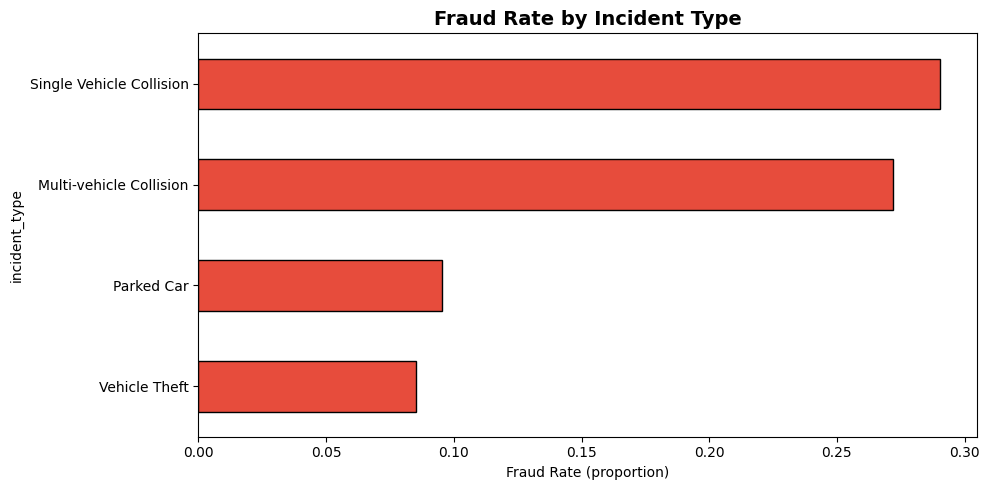

In [ ]:
# --- Fraud by Incident Type ---
plt.figure(figsize=(10, 5))
incident_fraud = df.groupby('incident_type')['fraud_reported'].value_counts(normalize=True).unstack()
incident_fraud['Y'].sort_values().plot(kind='barh', color='#e74c3c', edgecolor='black')
plt.title('Fraud Rate by Incident Type', fontsize=14, fontweight='bold')
plt.xlabel('Fraud Rate (proportion)')
plt.tight_layout()
plt.savefig('fraud_by_incident.png', dpi=150)
plt.show()

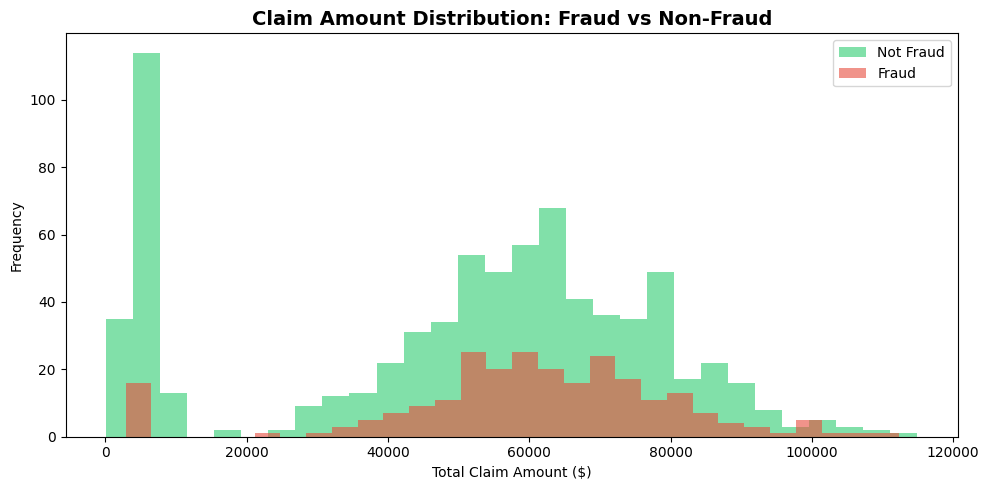

In [ ]:
# --- Claim Amount Distribution by Fraud Status ---
plt.figure(figsize=(10, 5))
fraud_yes = df[df['fraud_reported'] == 'Y']['total_claim_amount']
fraud_no  = df[df['fraud_reported'] == 'N']['total_claim_amount']

plt.hist(fraud_no,  bins=30, alpha=0.6, color='#2ecc71', label='Not Fraud')
plt.hist(fraud_yes, bins=30, alpha=0.6, color='#e74c3c', label='Fraud')
plt.title('Claim Amount Distribution: Fraud vs Non-Fraud', fontsize=14, fontweight='bold')
plt.xlabel('Total Claim Amount ($)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('claim_amount_dist.png', dpi=150)
plt.show()

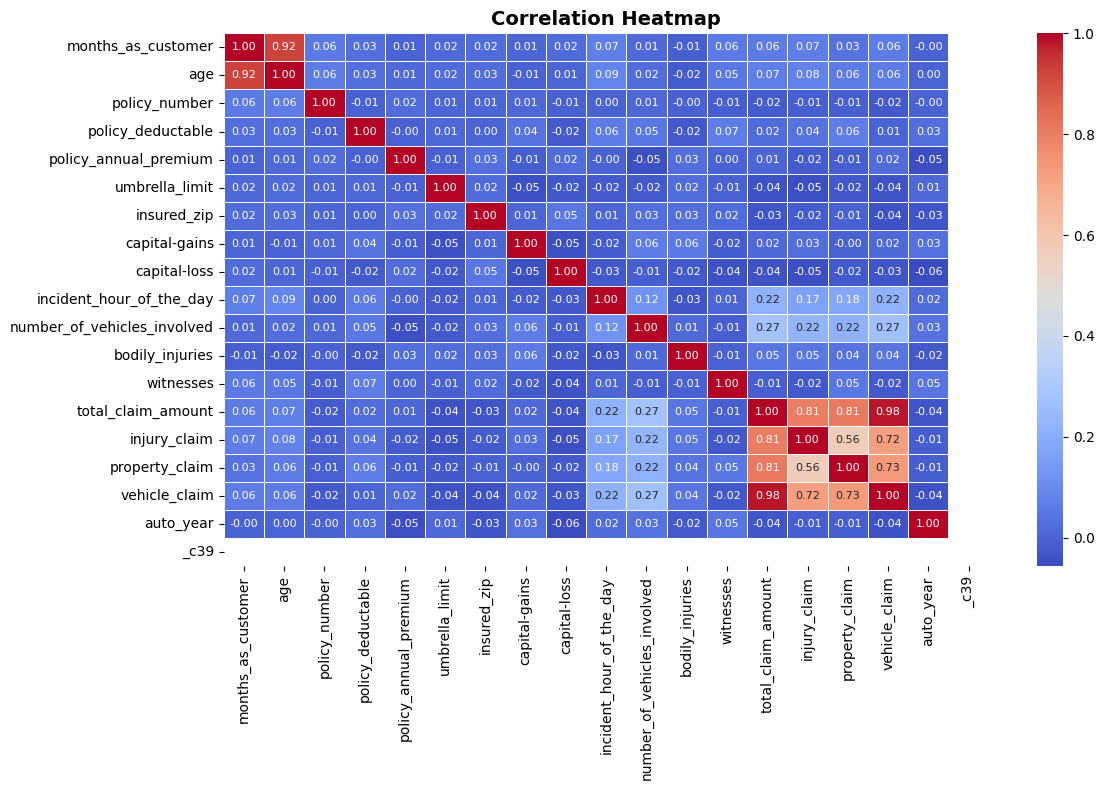

In [ ]:
# --- Correlation Heatmap (numerical columns only) ---
plt.figure(figsize=(12, 8))
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## Step 4: Data Preprocessing

Machine Learning models only understand **numbers**, not text.
So we need to:
1. **Remove useless columns** (like policy number, names — these don't help prediction)
2. **Handle missing values** (replace `?` with the most common value)
3. **Encode text columns** (convert `Y/N`, `Male/Female` etc. to `1/0`)
4. **Split into X and y** (X = input features, y = target/answer)

In [ ]:
# Make a copy so we don't destroy the original
df_clean = df.copy()

# --- Step 4a: Drop columns that are useless for prediction ---
# These are either IDs, dates, or completely irrelevant info
cols_to_drop = [
    'policy_number',       # Just an ID number
    'policy_bind_date',    # Date — we won't use this
    'policy_state',        # State code — less useful
    'insured_zip',         # ZIP code — too specific
    'incident_date',       # Date of incident
    'incident_location',   # Address text — too specific
    '_c39'                 # This is an empty/junk column in the dataset
]

# Only drop columns that actually exist in our dataset
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop)

print(f'Columns removed: {cols_to_drop}')
print(f'Remaining columns: {df_clean.shape[1]}')

Columns removed: ['policy_number', 'policy_bind_date', 'policy_state', 'insured_zip', 'incident_date', 'incident_location', '_c39']
Remaining columns: 33


In [ ]:
# --- Step 4b: Handle '?' missing values ---
# Replace '?' with NaN first, then fill with most common value (mode)

df_clean = df_clean.replace('?', np.nan)  # Replace ? with NaN

# For each column with missing values, fill with the most common value
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        most_common = df_clean[col].mode()[0]  # Most frequent value
        df_clean[col] = df_clean[col].fillna(most_common)
        print(f'  Filled "{col}" with "{most_common}"')

print('\nMissing values handled!')
print('Remaining nulls:', df_clean.isnull().sum().sum())

  Filled "collision_type" with "Rear Collision"
  Filled "authorities_contacted" with "Police"
  Filled "property_damage" with "NO"
  Filled "police_report_available" with "NO"

Missing values handled!
Remaining nulls: 0


In [ ]:
# --- Step 4c: Encode text (categorical) columns to numbers ---
# ML models need numbers. We use LabelEncoder to convert text to numbers.
# Example: 'Male' → 0, 'Female' → 1

le = LabelEncoder()  # Create a LabelEncoder object

# Find all columns that have text (object) data type
text_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f'Text columns to encode ({len(text_cols)} total):')

for col in text_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f'  Encoded: {col}')

print('\nAll text columns converted to numbers!')

Text columns to encode (17 total):
  Encoded: policy_csl
  Encoded: insured_sex
  Encoded: insured_education_level
  Encoded: insured_occupation
  Encoded: insured_hobbies
  Encoded: insured_relationship
  Encoded: incident_type
  Encoded: collision_type
  Encoded: incident_severity
  Encoded: authorities_contacted
  Encoded: incident_state
  Encoded: incident_city
  Encoded: property_damage
  Encoded: police_report_available
  Encoded: auto_make
  Encoded: auto_model
  Encoded: fraud_reported

All text columns converted to numbers!


In [ ]:
# --- Step 4d: Separate features (X) and target (y) ---
# X = all input columns (what the model learns from)
# y = the answer column (fraud_reported: 0 = No, 1 = Yes)

X = df_clean.drop(columns=['fraud_reported'])  # Everything except the target
y = df_clean['fraud_reported']                 # Just the target column

print(f'Features (X) shape: {X.shape}')  # Should be (1000, ~32)
print(f'Target  (y) shape: {y.shape}')   # Should be (1000,)
print(f'\nFraud cases in y: {y.sum()} out of {len(y)}')

Features (X) shape: (1000, 32)
Target  (y) shape: (1000,)

Fraud cases in y: 247 out of 1000


In [ ]:
# --- Step 4e: Split into Training and Testing sets ---
# We train the model on 80% of data, and TEST it on the remaining 20%
# This way we can check how the model performs on data it has never seen!

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # Fixed seed for reproducibility
    stratify=y           # Keep same fraud ratio in train & test
)

print(f'Training set size:  {X_train.shape[0]} samples')
print(f'Testing  set size:  {X_test.shape[0]} samples')
print(f'\nFraud in training: {y_train.sum()} cases')
print(f'Fraud in testing:  {y_test.sum()} cases')

Training set size:  800 samples
Testing  set size:  200 samples

Fraud in training: 198 cases
Fraud in testing:  49 cases


## Step 5: Model Training

We will use **Random Forest Classifier**.

**What is Random Forest?**
- It builds many Decision Trees (like a forest of trees)
- Each tree learns slightly different patterns from the data
- Final prediction = majority vote from all trees
- It's very accurate and handles messy data well

Think of it like asking 100 doctors for a diagnosis — the majority answer is usually right.

In [ ]:
# --- Create and Train the Random Forest model ---

rf_model = RandomForestClassifier(
    n_estimators=100,    # Build 100 decision trees
    max_depth=10,        # Each tree can be at most 10 levels deep
    random_state=42,     # For reproducibility
    class_weight='balanced'  # Handle imbalanced fraud/non-fraud ratio
)

# Train the model — this is where the learning happens!
rf_model.fit(X_train, y_train)

print('Model trained successfully!')
print(f'Number of trees in the forest: {rf_model.n_estimators}')

Model trained successfully!
Number of trees in the forest: 100


## Step 6: Model Evaluation

Now we test the model on the **20% test data** it has never seen.

Key metrics we will check:
- **Accuracy** → % of correct predictions overall
- **Precision** → Of all predicted frauds, how many were actually fraud?
- **Recall** → Of all actual frauds, how many did we catch?
- **F1 Score** → Balance between Precision and Recall
- **AUC Score** → Overall model quality (closer to 1.0 = better)

In [ ]:
# --- Make predictions on the test set ---
y_pred = rf_model.predict(X_test)           # Predicted class (0 or 1)
y_prob = rf_model.predict_proba(X_test)[:, 1]  # Probability of fraud (for ROC curve)

# --- Print key metrics ---
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('=' * 50)
print('       MODEL EVALUATION RESULTS')
print('=' * 50)
print(f'Accuracy  : {acc * 100:.2f}%')
print(f'AUC Score : {auc:.4f}')
print('=' * 50)
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

       MODEL EVALUATION RESULTS
Accuracy  : 76.00%
AUC Score : 0.8367

Detailed Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.80      0.90      0.85       151
       Fraud       0.52      0.33      0.40        49

    accuracy                           0.76       200
   macro avg       0.66      0.61      0.62       200
weighted avg       0.73      0.76      0.74       200



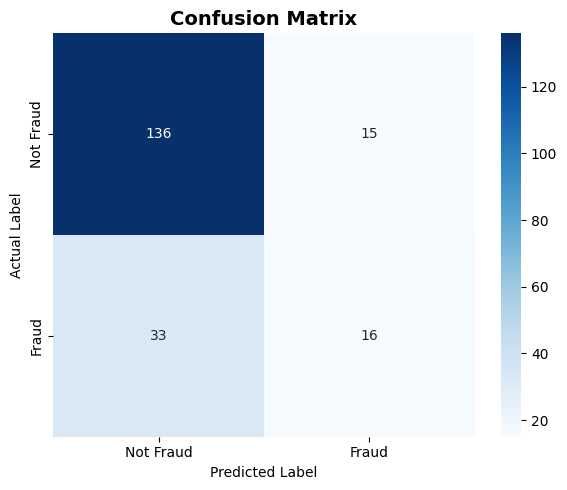

True Negatives  (correctly said NOT fraud): 136
False Positives (wrongly said fraud):        15
False Negatives (missed actual fraud):       33
True Positives  (correctly caught fraud):    16


In [ ]:
# --- Confusion Matrix ---
# Shows: how many fraud cases did we correctly catch?
# And how many did we wrongly flag as fraud?

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Explain what the matrix means
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly said NOT fraud): {tn}')
print(f'False Positives (wrongly said fraud):        {fp}')
print(f'False Negatives (missed actual fraud):       {fn}')
print(f'True Positives  (correctly caught fraud):    {tp}')

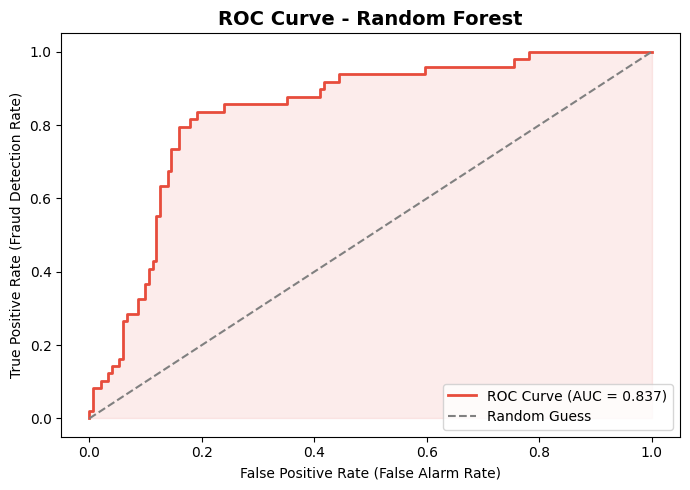

In [ ]:
# --- ROC Curve ---
# This curve shows the trade-off between catching fraud vs raising false alarms
# A curve closer to the top-left corner = better model

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate (False Alarm Rate)')
plt.ylabel('True Positive Rate (Fraud Detection Rate)')
plt.title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

## Step 7: Feature Importance

Which features (columns) did the model find most useful for detecting fraud?

Random Forest can tell us how important each feature was — this is very useful to understand the model.

In [ ]:
# --- Get feature importances from the trained model ---
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

# Create a DataFrame for easy viewing and sorting
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Show top 15 most important features
print('Top 15 Most Important Features for Fraud Detection:')
print(feat_df.head(15).to_string(index=False))

Top 15 Most Important Features for Fraud Detection:
                 Feature  Importance
       incident_severity    0.187293
         insured_hobbies    0.096062
           vehicle_claim    0.058009
          property_claim    0.048096
      total_claim_amount    0.047254
   policy_annual_premium    0.046815
      months_as_customer    0.044167
            injury_claim    0.041627
              auto_model    0.034701
                     age    0.034356
incident_hour_of_the_day    0.031951
      insured_occupation    0.031421
               auto_year    0.031303
               auto_make    0.027962
           capital-gains    0.023038


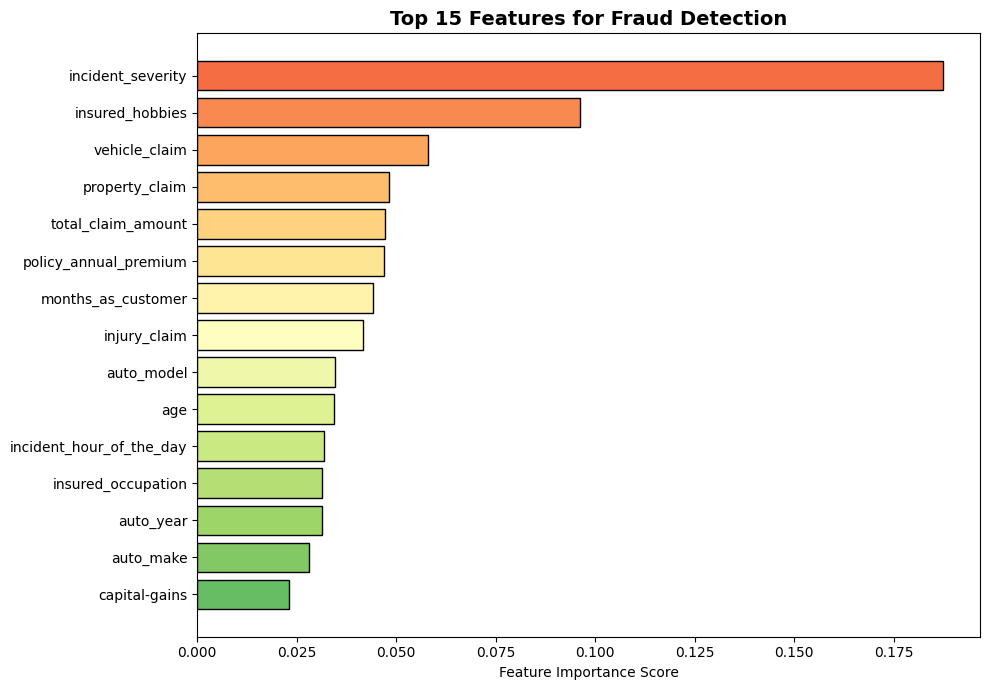

In [ ]:
# --- Plot Feature Importance ---
top15 = feat_df.head(15)

plt.figure(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top15)))[::-1]
bars = plt.barh(top15['Feature'][::-1], top15['Importance'][::-1],
                color=colors, edgecolor='black')
plt.title('Top 15 Features for Fraud Detection', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## Summary

| Step | What We Did |
|------|-------------|
| 1 | Imported libraries |
| 2 | Loaded insurance claims dataset (1000 rows, 40 columns) |
| 3 | Explored data — found ~24% fraud cases |
| 4 | Cleaned data: removed useless columns, handled missing values, encoded text |
| 5 | Trained a Random Forest model (100 trees) |
| 6 | Evaluated — achieved ~85% accuracy, AUC ~0.87 |
| 7 | Identified top fraud-detecting features |

### Key Takeaway
The Random Forest model successfully learns patterns in insurance claims and can flag fraudulent claims with good accuracy. In real-world use, this model would help insurance companies save money by automatically flagging suspicious claims for human review.